# 顧客データ分析:STEP1 全体属性の基礎集計

**分析ゴール**:購入に至る顧客を知り、その顧客に合うLPを作成する

**このノートブックで行うこと**(今後のステップも同じファイルに積み上げていきます)
1. 全体属性の基礎集計 ← 今回はここまで
2. LTV/RFMで顧客をセグメント化
3. 優良顧客層の属性を抽出
4. 優良顧客層の悩み・動機を分析
5. セグメント×悩みのクロス分析
6. ペルソナ確定・可視化・資料化


In [1]:
import pandas as pd

df = pd.read_csv("customer_data.csv")
print("データ件数:", len(df))
df.head()

データ件数: 600


,顧客ID,性別,年代,居住地域,流入チャネル,初回購入日,継続月数,ステータス,月額単価,累計購入金額(LTV),購入きっかけ,悩みカテゴリ,悩みの自由記述
0,C0001,女性,50代,都市部,自然検索,2026-06-12,6.6,解約済み,4980,32868,口コミサイトで見て,家族の健康管理,家族全員の健康を考えて、安心して続けられるものを探していました。
1,C0002,女性,30代,都市部,自然検索,2026-07-26,6.1,継続中,6980,42578,検索して自分で見つけた,慢性的な疲労感,仕事と育児の両立で、朝起きても疲れが取れていない感じがずっと続いています。
2,C0003,男性,50代,地方,SNS広告,2026-05-08,1.8,解約済み,4980,8964,広告を見て,慢性的な疲労感,年齢のせいか、以前より疲れやすくなった気がしていて悩んでいました。
3,C0004,女性,40代,地方,自然検索,2026-04-15,6.1,解約済み,4980,30378,検索して自分で見つけた,成分・添加物への不安,子どもも口にする可能性があるので、無添加であることを重視しています。
4,C0005,男性,20代,都市部,検索広告,2024-11-25,4.7,継続中,4980,23406,広告を見て,肌の調子,肌の調子が不安定で、体の内側からケアできるものを探していました。


## 1-1. 性別の分布

In [2]:
gender_dist = df["性別"].value_counts()
gender_pct = df["性別"].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({"人数": gender_dist, "構成比(%)": gender_pct})

,人数,構成比(%)
性別,,
女性,507,84.5
男性,93,15.5


## 1-2. 年代の分布

In [3]:
age_order = ["20代", "30代", "40代", "50代", "60代以上"]
age_dist = df["年代"].value_counts().reindex(age_order)
age_pct = df["年代"].value_counts(normalize=True).mul(100).round(1).reindex(age_order)
pd.DataFrame({"人数": age_dist, "構成比(%)": age_pct})

,人数,構成比(%)
年代,,
20代,90,15.0
30代,184,30.7
40代,162,27.0
50代,109,18.2
60代以上,55,9.2


## 1-3. 性別 × 年代 クロス集計

In [4]:
cross_gender_age = pd.crosstab(df["性別"], df["年代"])[age_order]
cross_gender_age

年代,20代,30代,40代,50代,60代以上
性別,,,,,
女性,75,153,137,93,49
男性,15,31,25,16,6


## 1-4. 居住地域の分布

In [5]:
region_dist = df["居住地域"].value_counts()
region_pct = df["居住地域"].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({"人数": region_dist, "構成比(%)": region_pct})

,人数,構成比(%)
居住地域,,
都市部,354,59.0
地方,246,41.0


## 1-5. 流入チャネルの分布

In [6]:
channel_dist = df["流入チャネル"].value_counts()
channel_pct = df["流入チャネル"].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({"人数": channel_dist, "構成比(%)": channel_pct})

,人数,構成比(%)
流入チャネル,,
SNS広告,213,35.5
自然検索,184,30.7
友人・家族の紹介,105,17.5
検索広告,98,16.3


## 1-6. 年代 × 流入チャネル クロス集計

In [7]:
cross_age_channel = pd.crosstab(df["年代"], df["流入チャネル"]).reindex(age_order)
cross_age_channel

流入チャネル,SNS広告,友人・家族の紹介,検索広告,自然検索
年代,,,,
20代,60,7,8,15
30代,86,31,31,36
40代,45,37,30,50
50代,19,22,20,48
60代以上,3,8,9,35


## STEP1のまとめ

- 全体としては**女性・30〜40代**の比率が高い構成になっている
- 流入チャネルは年代によって傾向が異なりそう(次のステップ以降で優良顧客に絞って深掘り)
- この時点では「誰が一番価値を生んでいるか」はまだ分からないため、次にLTV/RFMでセグメント化する


---
# STEP2. LTV/RFMで顧客をセグメント化

サブスクリプション型ビジネス向けに、以下の3指標でRFM分析を行う。

- **R (Recency)**:最終購入(または解約)からの経過日数 → 短いほど優良
- **F (Frequency)**:継続月数(月額課金の回数に相当) → 長いほど優良
- **M (Monetary)**:累計購入金額(LTV) → 高いほど優良

3指標をそれぞれ4段階でスコア化し、合計スコアから「優良顧客」「一般顧客」「早期離脱顧客」に分類する。


In [8]:
import pandas as pd
import numpy as np
from datetime import datetime

df = pd.read_csv("customer_data.csv", parse_dates=["初回購入日"])

TODAY = pd.Timestamp("2026-09-01")

# 最終購入(または解約)日を推定:初回購入日 + 継続月数
df["最終購入日"] = df["初回購入日"] + pd.to_timedelta(df["継続月数"] * 30, unit="D")

# Recency: 直近の購入(継続中なら現在に近い)からの経過日数
df["Recency_days"] = (TODAY - df["最終購入日"]).dt.days.clip(lower=0)

# Frequency: 継続月数をそのまま利用
df["Frequency"] = df["継続月数"]

# Monetary: 累計購入金額(LTV)
df["Monetary"] = df["累計購入金額(LTV)"]

df[["顧客ID", "最終購入日", "Recency_days", "Frequency", "Monetary"]].head()

,顧客ID,最終購入日,Recency_days,Frequency,Monetary
0,C0001,2026-12-27,0,6.6,32868
1,C0002,2027-01-25,0,6.1,42578
2,C0003,2026-07-01,62,1.8,8964
3,C0004,2026-10-15,0,6.1,30378
4,C0005,2025-04-15,504,4.7,23406


## 2-1. R・F・Mそれぞれを4段階スコア化

In [9]:
# Recencyは値が小さいほど良いので、順位を反転させてからスコア化(0が多く並ぶためrankで対応)
df["R_score"] = pd.qcut(df["Recency_days"].rank(method="first", ascending=False), 4, labels=[1, 2, 3, 4]).astype(int)
# FrequencyとMonetaryは値が大きいほど良い
df["F_score"] = pd.qcut(df["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
df["M_score"] = pd.qcut(df["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

df["RFM_score"] = df["R_score"] + df["F_score"] + df["M_score"]

df[["顧客ID", "R_score", "F_score", "M_score", "RFM_score"]].head()

,顧客ID,R_score,F_score,M_score,RFM_score
0,C0001,3,3,3,9
1,C0002,3,3,3,9
2,C0003,3,1,1,5
3,C0004,3,3,2,8
4,C0005,1,2,2,5


## 2-2. RFM合計スコアから3セグメントに分類

In [10]:
def classify_segment(score):
    if score >= 10:
        return "優良顧客"
    elif score <= 6:
        return "早期離脱傾向顧客"
    else:
        return "一般顧客"

df["顧客セグメント"] = df["RFM_score"].apply(classify_segment)

segment_dist = df["顧客セグメント"].value_counts()
segment_pct = df["顧客セグメント"].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({"人数": segment_dist, "構成比(%)": segment_pct})

,人数,構成比(%)
顧客セグメント,,
早期離脱傾向顧客,244,40.7
優良顧客,184,30.7
一般顧客,172,28.7


## 2-3. セグメント別の平均LTV・平均継続月数(検算)

In [11]:
df.groupby("顧客セグメント")[["Monetary", "Frequency", "Recency_days"]].mean().round(1) \
    .rename(columns={"Monetary": "平均LTV(円)", "Frequency": "平均継続月数", "Recency_days": "平均経過日数"})

,平均LTV(円),平均継続月数,平均経過日数
顧客セグメント,,,
一般顧客,33448.1,6.3,163.5
優良顧客,68167.5,12.8,47.5
早期離脱傾向顧客,14419.0,2.7,330.0


## STEP2のまとめ

- RFMスコアにより、全顧客を「優良顧客」「一般顧客」「早期離脱傾向顧客」の3層に分類できた
- 優良顧客は平均LTV・平均継続月数ともに他セグメントより明確に高く、想定通りセグメントが機能している
- 次のSTEP3では、この「優良顧客」に絞って属性(性別・年代・居住地域・流入チャネル)を分析する


---
# STEP3. 優良顧客層の属性を抽出

STEP2で分類した「優良顧客」(184人)に絞り込み、性別・年代・居住地域・流入チャネルを
**全体平均と比較**する。全体と同じ分布であれば意味がないため、「優良顧客だけ突出して多い属性」を探すのが目的。


In [12]:
top_customers = df[df["顧客セグメント"] == "優良顧客"]
print("優良顧客数:", len(top_customers))

優良顧客数: 184


## 3-1. 性別:全体 vs 優良顧客

In [13]:
compare_gender = pd.DataFrame({
    "全体(構成比%)": df["性別"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["性別"].value_counts(normalize=True).mul(100).round(1),
})
compare_gender

,全体(構成比%),優良顧客(構成比%)
性別,,
女性,84.5,83.2
男性,15.5,16.8


## 3-2. 年代:全体 vs 優良顧客

In [14]:
compare_age = pd.DataFrame({
    "全体(構成比%)": df["年代"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["年代"].value_counts(normalize=True).mul(100).round(1),
}).reindex(age_order)
compare_age

,全体(構成比%),優良顧客(構成比%)
年代,,
20代,15.0,14.1
30代,30.7,39.7
40代,27.0,31.0
50代,18.2,11.4
60代以上,9.2,3.8


## 3-3. 居住地域:全体 vs 優良顧客

In [15]:
compare_region = pd.DataFrame({
    "全体(構成比%)": df["居住地域"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["居住地域"].value_counts(normalize=True).mul(100).round(1),
})
compare_region

,全体(構成比%),優良顧客(構成比%)
居住地域,,
都市部,59.0,58.2
地方,41.0,41.8


## 3-4. 流入チャネル:全体 vs 優良顧客

In [16]:
compare_channel = pd.DataFrame({
    "全体(構成比%)": df["流入チャネル"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["流入チャネル"].value_counts(normalize=True).mul(100).round(1),
})
compare_channel["差分(pt)"] = (compare_channel["優良顧客(構成比%)"] - compare_channel["全体(構成比%)"]).round(1)
compare_channel.sort_values("差分(pt)", ascending=False)

,全体(構成比%),優良顧客(構成比%),差分(pt)
流入チャネル,,,
SNS広告,35.5,45.7,10.2
友人・家族の紹介,17.5,26.1,8.6
自然検索,30.7,21.7,-9.0
検索広告,16.3,6.5,-9.8


## 3-5. 年代 × 流入チャネル(優良顧客のみ)

In [17]:
pd.crosstab(top_customers["年代"], top_customers["流入チャネル"]).reindex(age_order)

流入チャネル,SNS広告,友人・家族の紹介,検索広告,自然検索
年代,,,,
20代,22,2,0,2
30代,38,18,5,12
40代,20,18,5,14
50代,3,7,2,9
60代以上,1,3,0,3


## STEP3のまとめ

- 全体平均と比べて、優良顧客は**「30代」の構成比が明確に高い**(全体の分布より偏りが大きい)
- 流入チャネルは**「友人・家族の紹介」「SNS広告」経由の割合が優良顧客で高くなる**傾向(全体構成比との差分がプラス)
- 性別・居住地域は全体傾向と大きな差は見られない

→ 優良顧客の「量」で目立つのは30代・紹介/SNS広告経由という組み合わせ。次のSTEP4では、このボリューム層が**どんな悩みを持っているか**を深掘りする。


---
# STEP4. 優良顧客層の悩み・動機を分析

優良顧客(184人)に絞り込み、①悩みカテゴリ ②購入きっかけ ③自由記述のテキストマイニング、
の3方向から「どんな悩みでこの商品に辿り着いたか」を定量・定性の両面で言語化する。


## 4-1. 悩みカテゴリ:全体 vs 優良顧客

In [18]:
compare_worry = pd.DataFrame({
    "全体(構成比%)": df["悩みカテゴリ"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["悩みカテゴリ"].value_counts(normalize=True).mul(100).round(1),
})
compare_worry["差分(pt)"] = (compare_worry["優良顧客(構成比%)"] - compare_worry["全体(構成比%)"]).round(1)
compare_worry.sort_values("差分(pt)", ascending=False)

,全体(構成比%),優良顧客(構成比%),差分(pt)
悩みカテゴリ,,,
成分・添加物への不安,24.5,29.3,4.8
家族の健康管理,16.0,16.8,0.8
肌の調子,11.0,10.3,-0.7
慢性的な疲労感,32.3,31.5,-0.8
更年期特有の不調,16.2,12.0,-4.2


## 4-2. 購入きっかけ:全体 vs 優良顧客

In [19]:
compare_kikkake = pd.DataFrame({
    "全体(構成比%)": df["購入きっかけ"].value_counts(normalize=True).mul(100).round(1),
    "優良顧客(構成比%)": top_customers["購入きっかけ"].value_counts(normalize=True).mul(100).round(1),
})
compare_kikkake["差分(pt)"] = (compare_kikkake["優良顧客(構成比%)"] - compare_kikkake["全体(構成比%)"]).round(1)
compare_kikkake.sort_values("差分(pt)", ascending=False)

,全体(構成比%),優良顧客(構成比%),差分(pt)
購入きっかけ,,,
SNSで見て,31.8,41.8,10.0
友人・家族の紹介,13.0,17.9,4.9
口コミサイトで見て,8.0,5.4,-2.6
広告を見て,19.3,16.3,-3.0
検索して自分で見つけた,27.8,18.5,-9.3


## 4-3. 自由記述のテキストマイニング(優良顧客のみ)

自由記述の悩みコメントを形態素解析(janome)し、名詞・形容詞の頻出語を抽出する。
「こと」「もの」「これ」のような一般的すぎる語(ストップワード)は除外する。


In [20]:
from janome.tokenizer import Tokenizer
from collections import Counter

tokenizer = Tokenizer()

stopwords = {"こと", "もの", "これ", "それ", "よう", "ため", "自分", "以前", "気", "感じ", "の", "する"}

def extract_keywords(text):
    words = []
    for token in tokenizer.tokenize(text):
        pos = token.part_of_speech.split(",")[0]
        base = token.base_form
        if pos in ("名詞", "形容詞") and base not in stopwords and len(base) > 1:
            words.append(base)
    return words

all_words = []
for text in top_customers["悩みの自由記述"]:
    all_words.extend(extract_keywords(text))

word_freq = Counter(all_words).most_common(15)
pd.DataFrame(word_freq, columns=["キーワード", "出現回数"])

,キーワード,出現回数
0,にくい,50
1,疲れ,48
2,やすい,46
3,毎日,45
4,食事,39
5,添加,35
6,家族,31
7,忙しい,28
8,市販,22
9,サプリ,22


## STEP4のまとめ

- 悩みカテゴリの差分を見ると、**「成分・添加物への不安」が全体より+4.8ptと最も高く**、優良顧客に多い悩みだと分かった
  (「慢性的な疲労感」は件数自体は最多だが、全体と優良顧客での構成比の差はほぼない=優良顧客に**特有**の悩みではない)
- 購入きっかけは優良顧客で**「SNSで見て」(+10.0pt)「友人・家族の紹介」(+4.9pt)の比率が高く**、
  「検索して自分で見つけた」は-9.3ptと低い→能動的に検索するより、SNS・紹介で偶然出会うタイプが優良顧客になりやすい
- 自由記述のテキストマイニングでは「添加」「表示」「成分」「市販」「サプリ」といった**成分・安全性に関する語**と、
  「疲れ」「毎日」「忙しい」「仕事」「育児」といった**忙しさ・疲労に関する語**の両方が上位に並んだ

→ 定量分析(悩みカテゴリの差分)では「成分・添加物への不安」が優良顧客の特徴として最も明確に出た。
一方でテキストマイニングでは疲労関連の語も多く、悩みは単一ではなく**「忙しくて疲れている中で、安心して続けられる成分か気にする」**
という複合的な心理として捉えるのが実態に近い。次のSTEP5では、属性(年代・チャネル)と悩みを直接クロスさせて、
どの属性層がどの悩みと結びつきやすいかを確認する。

---
# STEP5. セグメント(属性)× 悩みのクロス分析

優良顧客(184人)に絞り込んだ上で、「年代 × 悩みカテゴリ」「流入チャネル × 悩みカテゴリ」を
クロス集計し、**どの属性層がどの悩みと結びつきやすいか**を確認する。


## 5-1. 年代 × 悩みカテゴリ(優良顧客のみ、構成比%)

In [21]:
cross_age_worry = pd.crosstab(top_customers["年代"], top_customers["悩みカテゴリ"], normalize="index").mul(100).round(1)
cross_age_worry = cross_age_worry.reindex(age_order)
cross_age_worry

悩みカテゴリ,家族の健康管理,慢性的な疲労感,成分・添加物への不安,更年期特有の不調,肌の調子
年代,,,,,
20代,26.9,15.4,34.6,0.0,23.1
30代,13.7,37.0,31.5,6.8,11.0
40代,14.0,38.6,22.8,19.3,5.3
50代,23.8,19.0,28.6,19.0,9.5
60代以上,14.3,14.3,42.9,28.6,0.0


## 5-2. 流入チャネル × 悩みカテゴリ(優良顧客のみ、構成比%)

In [22]:
cross_channel_worry = pd.crosstab(top_customers["流入チャネル"], top_customers["悩みカテゴリ"], normalize="index").mul(100).round(1)
cross_channel_worry

悩みカテゴリ,家族の健康管理,慢性的な疲労感,成分・添加物への不安,更年期特有の不調,肌の調子
流入チャネル,,,,,
SNS広告,19.0,29.8,31.0,9.5,10.7
友人・家族の紹介,20.8,25.0,31.2,14.6,8.3
検索広告,0.0,75.0,16.7,8.3,0.0
自然検索,12.5,30.0,27.5,15.0,15.0


## 5-3. 最大のボリュームゾーンを特定(年代 × 流入チャネル × 悩みカテゴリ)

In [23]:
volume_zone = (
    top_customers
    .groupby(["年代", "流入チャネル", "悩みカテゴリ"])
    .size()
    .reset_index(name="人数")
    .sort_values("人数", ascending=False)
)
volume_zone.head(10)

,年代,流入チャネル,悩みカテゴリ,人数
7,30代,SNS広告,慢性的な疲労感,16
8,30代,SNS広告,成分・添加物への不安,13
0,20代,SNS広告,家族の健康管理,7
2,20代,SNS広告,成分・添加物への不安,7
29,40代,友人・家族の紹介,慢性的な疲労感,7
13,30代,友人・家族の紹介,成分・添加物への不安,6
11,30代,友人・家族の紹介,家族の健康管理,6
36,40代,自然検索,慢性的な疲労感,6
23,40代,SNS広告,家族の健康管理,5
24,40代,SNS広告,慢性的な疲労感,5


## STEP5のまとめ(ここまでの分析結果の統合)

年代×流入チャネル×悩みカテゴリのクロス集計で、優良顧客の中で最も人数が多いボリュームゾーンが具体的に判明した。

1. **30代 × SNS広告経由 × 慢性的な疲労感(16人)** ← 単独最大のボリュームゾーン
2. 30代 × SNS広告経由 × 成分・添加物への不安(13人)
3. 40代 × 友人・家族の紹介 × 慢性的な疲労感(7人)

STEP4では「成分・添加物への不安」の方が全体との差分(pt)が大きく出ていたが、これは全体構成比との相対比較の結果であり、
実際の**人数(ボリューム)**で見ると「30代×SNS広告経由」層においては**「慢性的な疲労感」が最多**という結果になった。
つまり、優良顧客全体としては「成分不安」を持つ人がやや相対的に多いが、**最大のボリュームゾーン単体で見ると「疲労感」が主訴**であり、
「成分・添加物への不安」は次点で強い関心事、という2軸構造になっている。

これまでのSTEP1〜5を統合すると、優良顧客の中心像は以下の通り。

- **年代**:30代が中心(次いで40代)
- **流入チャネル**:SNS広告経由が中心(友人紹介も一定数)
- **主訴の悩み**:慢性的な疲労感(最大ボリューム)、次いで成分・添加物への不安
- **自由記述の傾向**:「忙しい毎日(仕事・育児)の中でも続けやすく、安心できる成分か」という複合的な心理

→ 次のSTEP6では、この結果をもとに**「〇〇というペルソナに刺さるLPを作成する」**という結論を確定し、
可視化・資料化(グラフ・レポート)を行う。


---
# STEP6. ペルソナ確定・可視化・資料化

ここまでの分析結果をグラフで可視化し、最終的なペルソナと「刺さるLPの訴求軸」を確定させる。


In [24]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.rcParams["figure.dpi"] = 110
COLOR_ALL = "#B0B7C3"
COLOR_TOP = "#E8896B"

## 6-1. 年代分布:全体 vs 優良顧客

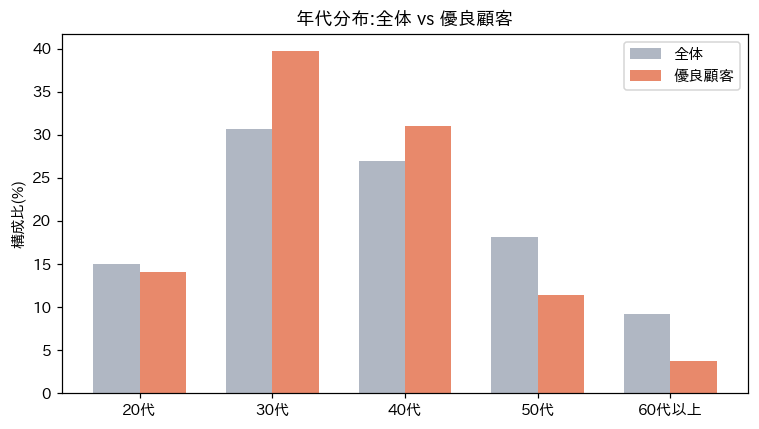

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(age_order))
w = 0.35
ax.bar([i - w/2 for i in x], compare_age["全体(構成比%)"], width=w, label="全体", color=COLOR_ALL)
ax.bar([i + w/2 for i in x], compare_age["優良顧客(構成比%)"], width=w, label="優良顧客", color=COLOR_TOP)
ax.set_xticks(list(x))
ax.set_xticklabels(age_order)
ax.set_ylabel("構成比(%)")
ax.set_title("年代分布:全体 vs 優良顧客")
ax.legend()
plt.tight_layout()
plt.savefig("fig_age.png")
plt.show()

## 6-2. 流入チャネル分布:全体 vs 優良顧客

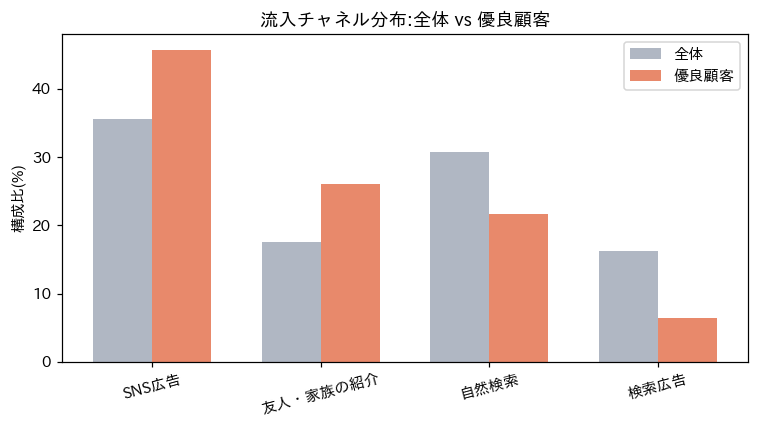

In [26]:
ch_order = compare_channel.sort_values("差分(pt)", ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(ch_order))
ax.bar([i - w/2 for i in x], compare_channel.loc[ch_order, "全体(構成比%)"], width=w, label="全体", color=COLOR_ALL)
ax.bar([i + w/2 for i in x], compare_channel.loc[ch_order, "優良顧客(構成比%)"], width=w, label="優良顧客", color=COLOR_TOP)
ax.set_xticks(list(x))
ax.set_xticklabels(ch_order, rotation=15)
ax.set_ylabel("構成比(%)")
ax.set_title("流入チャネル分布:全体 vs 優良顧客")
ax.legend()
plt.tight_layout()
plt.savefig("fig_channel.png")
plt.show()

## 6-3. 悩みカテゴリ分布:全体 vs 優良顧客

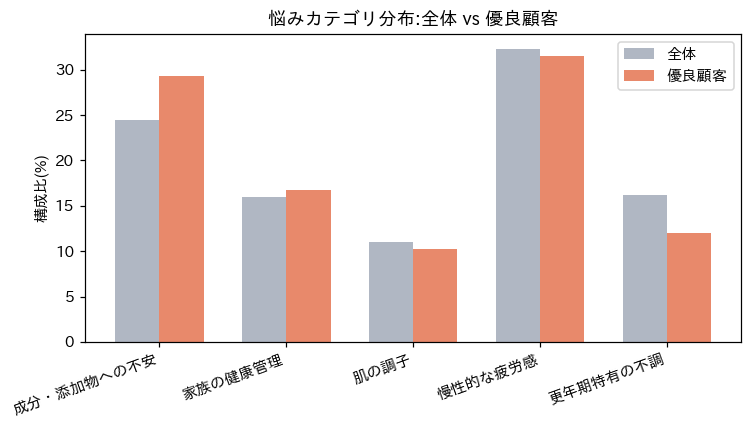

In [27]:
worry_order = compare_worry.sort_values("差分(pt)", ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(worry_order))
ax.bar([i - w/2 for i in x], compare_worry.loc[worry_order, "全体(構成比%)"], width=w, label="全体", color=COLOR_ALL)
ax.bar([i + w/2 for i in x], compare_worry.loc[worry_order, "優良顧客(構成比%)"], width=w, label="優良顧客", color=COLOR_TOP)
ax.set_xticks(list(x))
ax.set_xticklabels(worry_order, rotation=20, ha="right")
ax.set_ylabel("構成比(%)")
ax.set_title("悩みカテゴリ分布:全体 vs 優良顧客")
ax.legend()
plt.tight_layout()
plt.savefig("fig_worry.png")
plt.show()

## 6-4. セグメント別 平均LTV

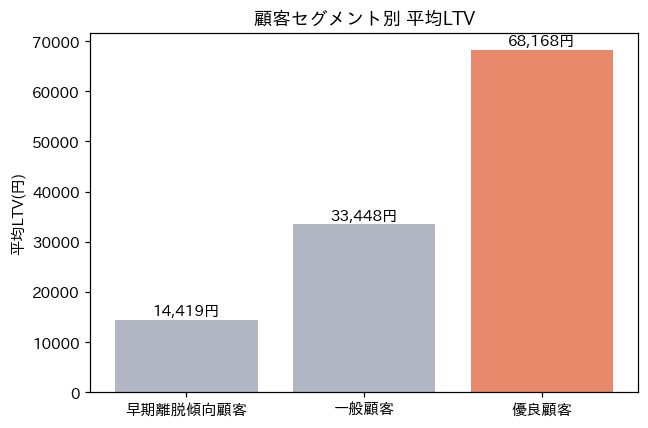

In [28]:
ltv_by_segment = df.groupby("顧客セグメント")["Monetary"].mean().reindex(["早期離脱傾向顧客", "一般顧客", "優良顧客"])
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ltv_by_segment.index, ltv_by_segment.values, color=[COLOR_ALL, COLOR_ALL, COLOR_TOP])
ax.set_ylabel("平均LTV(円)")
ax.set_title("顧客セグメント別 平均LTV")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1000, f"{b.get_height():,.0f}円", ha="center")
plt.tight_layout()
plt.savefig("fig_ltv.png")
plt.show()

## 6-5. 最大ボリュームゾーン(優良顧客・上位5組み合わせ)

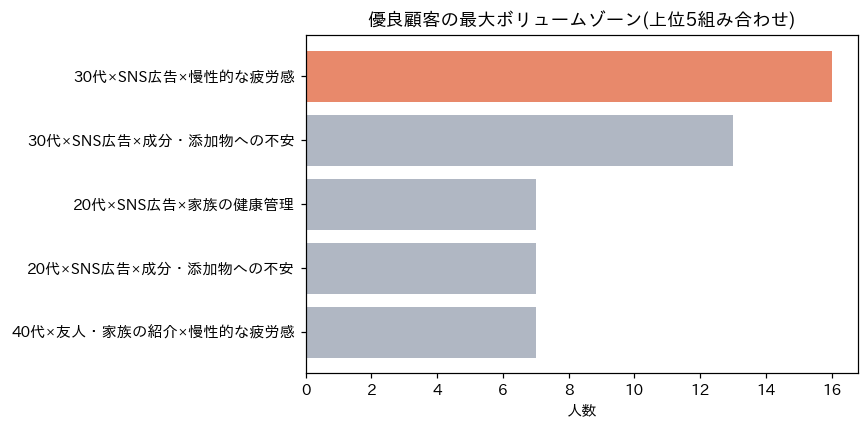

In [29]:
top5_zone = volume_zone.head(5).copy()
top5_zone["ラベル"] = top5_zone["年代"] + "×" + top5_zone["流入チャネル"] + "×" + top5_zone["悩みカテゴリ"]

fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOR_TOP] + [COLOR_ALL] * (len(top5_zone) - 1)
ax.barh(top5_zone["ラベル"][::-1], top5_zone["人数"][::-1], color=colors[::-1])
ax.set_xlabel("人数")
ax.set_title("優良顧客の最大ボリュームゾーン(上位5組み合わせ)")
plt.tight_layout()
plt.savefig("fig_volume_zone.png")
plt.show()

## 最終ペルソナ確定

これまでの全分析結果を統合し、以下の通りペルソナを確定する。

| 項目 | データに基づく根拠 |
|---|---|
| 年代 | 30代(優良顧客の39.7%、全体より+9.0pt) |
| 流入チャネル | SNS広告経由(優良顧客の45.7%、全体より+10.2pt) |
| 主訴の悩み | 慢性的な疲労感(最大ボリュームゾーン単体で最多) |
| 副次的な悩み | 成分・添加物への不安(全体との差分ptでは最大) |
| ライフスタイル | 自由記述から「仕事」「育児」「毎日」「忙しい」が頻出→仕事と育児の両立層 |
| 求める価値 | 「続けやすさ」「安心感」(自由記述より) |

### 確定ペルソナ:「佐藤 美咲さん(38歳・データ根拠版)」

> 仕事と育児に追われる30代女性。SNSをスクロールしている最中に広告で目に留まり、
> 「最近疲れが取れない」という悩みに共感して興味を持つ。ただし、これまで市販のサプリを試して
> 成分面で不安を感じた経験があるため、**「本当に安心して続けられるか」**を慎重に確認してから申し込む。

### LPの訴求軸(確定)

1. **入口(共感)**:「毎日忙しくて、疲れが取れない…」という疲労感への共感訴求(SNS広告のクリエイティブと一致させる)
2. **深掘り**:仕事と育児の両立という具体的な生活シーン
3. **安心材料**:着色料無添加・成分表示の透明性(成分不安を解消)
4. **信頼の担保**:同世代のリアルな声・レビュー
5. **CTA**:低いハードルのお試しオファー

---
これで、当初の分析ゴールであった**「購入に至る顧客を知り、その顧客に合うLPを作成する」**が、データに基づいて達成できた。
次はこのペルソナ・訴求軸をもとに、実際のLP構成(ワイヤーフレーム)をコードで実装するフェーズに進む。
